# CoPro Tutorial: One Cell Type (Intestinal Organoid)

This tutorial demonstrates how to run CoPro on a **single cell type** dataset. We use an intestinal organoid dataset profiled by seqFISH, where all cells are Epithelial. CoPro detects the **within-type spatial self-organization**: cells are arranged in a coordinated spatial progression even within a single cell type.

**What CoPro finds here:** The spatial co-progression of epithelial cells captures the crypt–villus axis of the organoid — cells along the same developmental trajectory cluster spatially.

## Overview

1. Load and preprocess gene expression data
2. Build a `CoProSingle` object
3. Run the full CoPro pipeline
4. Select the optimal sigma value
5. Visualize cell scores in space

## 1. Load packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import zscore

import copro as cp

print(f"copro version: {cp.__version__}")

copro version: 0.1.1


## 2. Set parameters

In [2]:
N_PCA = 30
CELL_TYPE = "Epithelial"          # single cell type
SIGMA_VALUES = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
N_CC = 4                          # number of canonical components

## 3. Load data

The input data consists of:
- **Expression matrix** — cells × genes, raw or pre-normalized counts
- **Metadata** — must include `x`, `y` spatial coordinates and a cell type column

Replace the paths below with your own files. The expression matrix can be a CSV (cells × genes) or any tabular format readable by pandas.

In [3]:
# ── Data paths ────────────────────────────────────────────────────────────────
DATA_DIR = "/Users/zhenmiao/Library/CloudStorage/Dropbox/DIALOGUE_plus project/Raj_lab_data/72hr/roi1/output"
EXPR_FILE = f"{DATA_DIR}/cell_by_gene/cell_by_gene.csv"
META_FILE = f"{DATA_DIR}/attributes/cell_attributes.csv"

expr_df = pd.read_csv(EXPR_FILE, index_col=0)
meta    = pd.read_csv(META_FILE)

# Match R vignette: label cells
meta["label"] = "cell_" + meta["label"].astype(str)
meta.index = meta["label"]
expr_df.index = meta["label"]

print(f"Cells: {expr_df.shape[0]}   Genes: {expr_df.shape[1]}")
meta.head()

Cells: 12011   Genes: 140


,label,area,center_x,center_y
label,,,,
cell_1,cell_1,7088,43,38
cell_2,cell_2,21736,2094,60
cell_3,cell_3,19014,2619,41
cell_4,cell_4,12254,2837,41
cell_5,cell_5,34312,10563,68


## 4. Preprocess

### 4a. Cap expression outliers

We cap each gene at its 95th percentile to reduce the influence of extreme values.

In [4]:
def cap_outliers(df: pd.DataFrame, upper_quantile: float = 0.95) -> pd.DataFrame:
    """Cap each gene column at the given quantile."""
    upper = df.quantile(upper_quantile, axis=0)
    return df.clip(upper=upper, axis=1)

expr_capped = cap_outliers(expr_df, upper_quantile=0.95)
print("Capped at 95th percentile.")

Capped at 95th percentile.


### 4b. Normalize expression

We apply a simple log1p normalization. For data with few measured genes (e.g. seqFISH panels of ~150 genes), total-count normalization is less reliable; you can substitute any normalization appropriate for your assay (e.g. DESeq2-equivalent size factor normalization).

In [5]:
# Normalize data (simple log1p — matches R vignette concept)
# For a more precise match to the R DESeq2 normalization, use a size-factor method.
expr_norm = np.log1p(expr_capped.values.astype(float))
print(f"Expression matrix shape after normalization: {expr_norm.shape}")

# Save gene names for later
gene_names = list(expr_df.columns)

Expression matrix shape after normalization: (12011, 140)


### 4c. Prepare spatial coordinates

Coordinates are scaled to a common unit. CoPro uses sigma values in the same unit as the coordinates, so scaling to a range of ~0–1 or physically meaningful units (e.g. mm) is recommended.

In [6]:
# Scale coordinates — adjust the divisor to match your coordinate units
# Here we scale by 5000 to convert pixels to approximate mm
location = pd.DataFrame({
    "x": meta["center_x"].values / 5000,
    "y": meta["center_y"].values / 5000,
})

# If your metadata already has x, y in the right units, use:
# location = meta[["x", "y"]].reset_index(drop=True)

# Assign a single cell type label to all cells
cell_types = np.array([CELL_TYPE] * len(meta))

### 4d. Visualize spatial layout

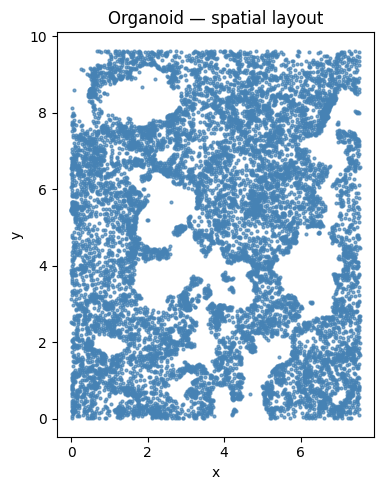

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(location["x"], location["y"], s=4, color="steelblue", alpha=0.7)
ax.set_title("Organoid — spatial layout")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Build CoPro object and run pipeline

The CoPro pipeline consists of six steps:

| Step | Function | Description |
|------|----------|-------------|
| 1 | `subset_data` | Filter to cell types of interest |
| 2 | `compute_pca` | PCA on expression matrix |
| 3 | `compute_distance` | Pairwise spatial distances |
| 4 | `compute_kernel_matrix` | Gaussian RBF kernel over distances |
| 5 | `run_skr_cca` | SkrCCA optimization (power method) |
| 6 | `compute_normalized_correlation` | Spectral-norm normalized CCA correlation |
| 7 | `compute_gene_and_cell_scores` | Project weights to cell and gene space |

In [8]:
# Build object
obj = cp.CoProSingle(
    normalized_data=expr_norm,
    location_data=location,
    meta_data=meta.reset_index(drop=True),
    cell_types=cell_types,
)

# Run pipeline
obj = cp.subset_data(obj, [CELL_TYPE])
obj = cp.compute_pca(obj, n_pca=N_PCA)
obj = cp.compute_distance(obj, normalize=False)
obj = cp.compute_kernel_matrix(
    obj,
    sigma_values=SIGMA_VALUES,
    upper_quantile=0.85,
    lower_limit=5e-7,
)
obj = cp.run_skr_cca(obj, scale_pcs=True, n_cc=N_CC)
obj = cp.compute_normalized_correlation(obj)
obj = cp.compute_gene_and_cell_scores(obj)

print(f"\nPipeline complete. Sigma choice: {obj.sigma_value_choice}")

Running SkrCCA for sigma = 0.01


Convergence reached at iteration 16 (max_diff=9.429e-06)
  Component convergence at iteration 0 (max_diff=2.776e-16)
  Component convergence at iteration 0 (max_diff=3.053e-16)
  Component convergence at iteration 0 (max_diff=4.441e-16)
Running SkrCCA for sigma = 0.02


Convergence reached at iteration 15 (max_diff=5.822e-06)
  Component convergence at iteration 0 (max_diff=7.910e-16)
  Component convergence at iteration 0 (max_diff=4.441e-16)
  Component convergence at iteration 0 (max_diff=2.776e-16)
Running SkrCCA for sigma = 0.05


Convergence reached at iteration 16 (max_diff=8.284e-06)
  Component convergence at iteration 0 (max_diff=3.331e-16)
  Component convergence at iteration 0 (max_diff=1.665e-16)
  Component convergence at iteration 0 (max_diff=2.498e-16)
Running SkrCCA for sigma = 0.1


Convergence reached at iteration 19 (max_diff=8.724e-06)
  Component convergence at iteration 0 (max_diff=2.776e-16)
  Component convergence at iteration 0 (max_diff=3.331e-16)
  Component convergence at iteration 0 (max_diff=3.331e-16)
Running SkrCCA for sigma = 0.15


Convergence reached at iteration 20 (max_diff=5.517e-06)
  Component convergence at iteration 0 (max_diff=4.510e-16)
  Component convergence at iteration 0 (max_diff=1.388e-16)
  Component convergence at iteration 0 (max_diff=2.359e-16)
Running SkrCCA for sigma = 0.2


Convergence reached at iteration 22 (max_diff=6.004e-06)
  Component convergence at iteration 0 (max_diff=6.661e-16)
  Component convergence at iteration 0 (max_diff=3.331e-16)
  Component convergence at iteration 0 (max_diff=5.551e-16)
Calculating spectral norms (may take a while)...


Finished calculating spectral norms.



Pipeline complete. Sigma choice: 0.2


## 6. Select optimal sigma

CoPro automatically selects the sigma value that maximizes the mean CC1 normalized correlation. We can visualize the normalized correlation across all tested sigma values and canonical components (CCs) to confirm the selection.

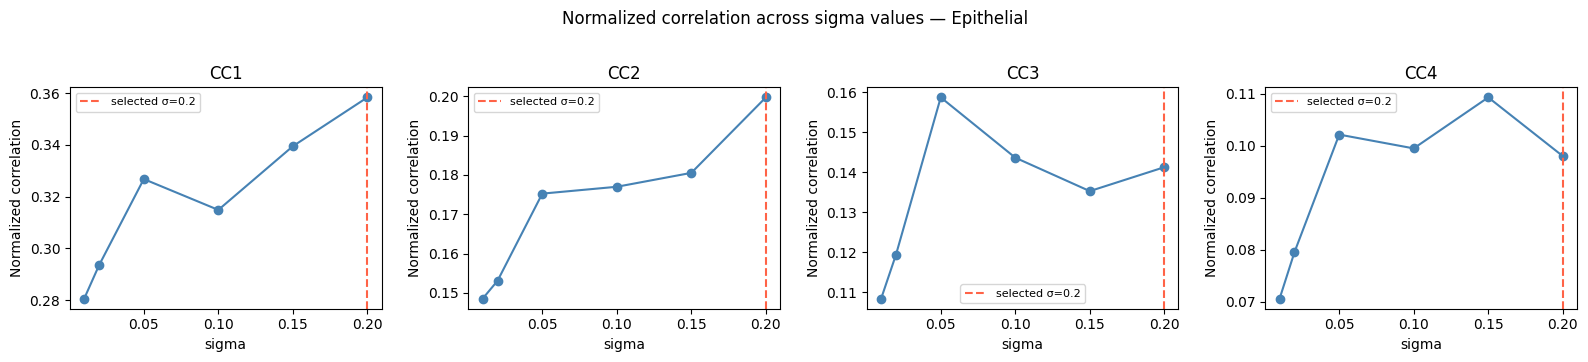

In [9]:
# Collect normalized correlations into one DataFrame
nc_frames = []
for sigma_name, df in obj.normalized_correlation.items():
    if df is not None and len(df) > 0:
        nc_frames.append(df)
nc_df = pd.concat(nc_frames, ignore_index=True)

# Plot: one panel per CC
cc_indices = sorted(nc_df["CC_index"].unique())
fig, axes = plt.subplots(1, len(cc_indices), figsize=(4 * len(cc_indices), 3.5), sharey=False)
if len(cc_indices) == 1:
    axes = [axes]

for ax, cc in zip(axes, cc_indices):
    sub = nc_df[nc_df["CC_index"] == cc].sort_values("sigma")
    ax.plot(sub["sigma"], sub["normalized_correlation"], "o-", color="steelblue")
    ax.axvline(obj.sigma_value_choice, color="tomato", linestyle="--", label=f"selected σ={obj.sigma_value_choice}")
    ax.set_title(f"CC{cc}")
    ax.set_xlabel("sigma")
    ax.set_ylabel("Normalized correlation")
    ax.legend(fontsize=8)

fig.suptitle(f"Normalized correlation across sigma values — {CELL_TYPE}", y=1.02)
plt.tight_layout()
plt.show()

## 7. Correlation scatter plot

For a within-type model, the objective is to find cell scores that are spatially correlated: cells close in space (as measured by the kernel) should have similar scores. We visualize this by plotting the **kernel-smoothed scores** (K·scores) against the **raw cell scores**.

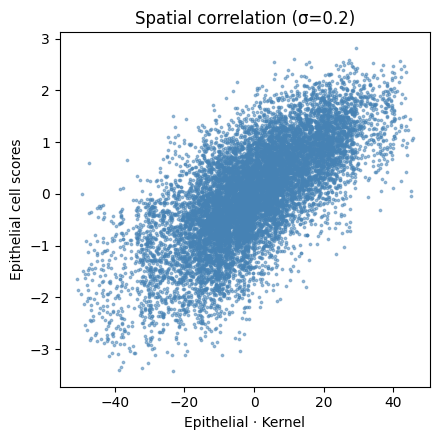

In [10]:
sigma = obj.sigma_value_choice
ct = CELL_TYPE

# Cell scores for CC1
scores = obj.cell_scores[f"cellScores|sigma{sigma}|{ct}"][:, 0]  # (n_cells,)

# Kernel matrix
K = obj.kernel_matrices[f"kernel|sigma{sigma}|{ct}|{ct}"]

# Kernel-smoothed scores: K @ scores
k_scores = K @ scores

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(k_scores, scores, s=3, alpha=0.5, color="steelblue")
ax.set_xlabel(f"{ct} · Kernel")
ax.set_ylabel(f"{ct} cell scores")
ax.set_title(f"Spatial correlation (σ={sigma})")
plt.tight_layout()
plt.show()

## 8. Cell scores in situ

We visualize the CoPro cell scores spatially. Cells with similar scores form coherent spatial regions, revealing the underlying tissue organization.

### 8a. Continuous scores

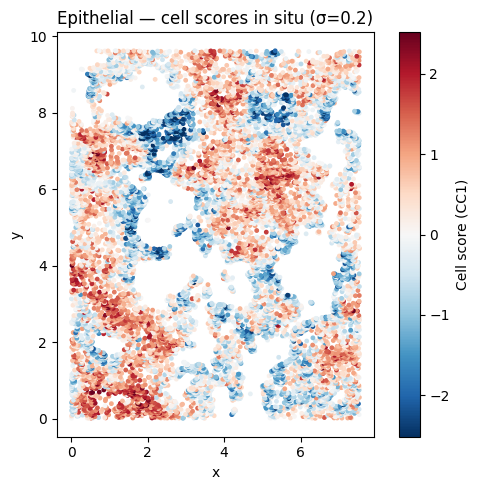

In [11]:
sigma = obj.sigma_value_choice
ct = CELL_TYPE

scores = obj.cell_scores[f"cellScores|sigma{sigma}|{ct}"][:, 0]

# Spatial coordinates of this cell type (same order as scores)
mask = obj.cell_types_sub == ct
loc_sub = obj.location_data_sub[mask].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(
    loc_sub["x"], loc_sub["y"],
    c=scores, cmap="RdBu_r", s=6, vmin=-np.percentile(np.abs(scores), 99),
    vmax=np.percentile(np.abs(scores), 99),
)
plt.colorbar(sc, ax=ax, label="Cell score (CC1)")
ax.set_title(f"{ct} — cell scores in situ (σ={sigma})")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### 8b. Binarized scores

We binarize the cell scores at the median to highlight the two spatial groups (high vs. low scoring cells).

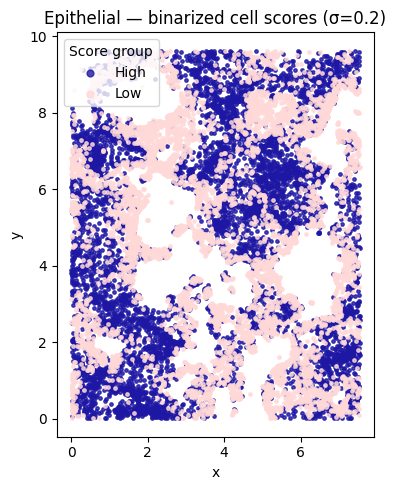

In [12]:
scores_binary = (scores > np.median(scores)).astype(int)
colors = np.where(scores_binary == 1, "#1e17a4", "#ffd8d8")

fig, ax = plt.subplots(figsize=(5.5, 5))
for label, color, name in [(1, "#1e17a4", "High"), (0, "#ffd8d8", "Low")]:
    sel = scores_binary == label
    ax.scatter(loc_sub.loc[sel, "x"], loc_sub.loc[sel, "y"], s=6, color=color, label=name, alpha=0.8)
ax.legend(title="Score group", markerscale=2)
ax.set_title(f"{ct} — binarized cell scores (σ={sigma})")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 9. Top genes associated with spatial progression

Gene scores reflect how strongly each gene is associated with the spatial co-progression axis. We display the top genes for CC1.

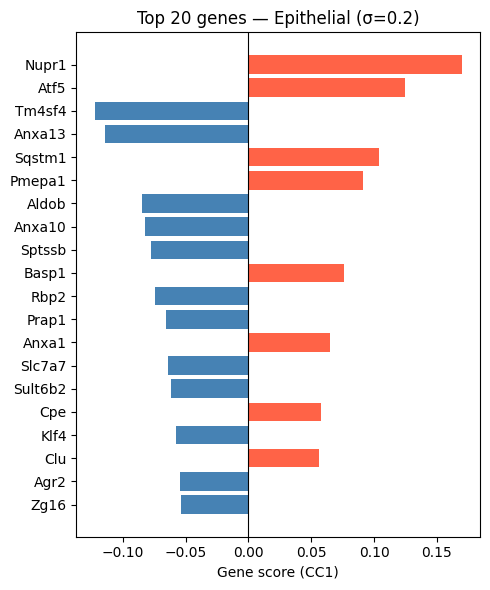

In [13]:
sigma = obj.sigma_value_choice
ct = CELL_TYPE
gs = obj.gene_scores[f"geneScores|sigma{sigma}|{ct}"][:, 0]  # (n_genes,)

gene_score_df = pd.DataFrame({"gene": gene_names, "score": gs})
gene_score_df = gene_score_df.reindex(gene_score_df["score"].abs().sort_values(ascending=False).index)

top_n = 20
top_genes = gene_score_df.head(top_n)

fig, ax = plt.subplots(figsize=(5, 6))
colors = ["tomato" if s > 0 else "steelblue" for s in top_genes["score"]]
ax.barh(top_genes["gene"][::-1], top_genes["score"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Gene score (CC1)")
ax.set_title(f"Top {top_n} genes — {ct} (σ={sigma})")
plt.tight_layout()
plt.show()

## References

**CoPro method:**  
Miao Z. et al. *CoPro: Unsupervised detection of coordinated spatial progressions in spatial transcriptomics* (in preparation).

**Organoid data:**  
Raj Lab intestinal organoid dataset.